In [48]:
import os
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Add the project root to the system path
if project_root not in sys.path:
    sys.path.append(project_root)

# Verify the path was added (optional)
print(f"Project root added to sys.path: {project_root}")

Project root added to sys.path: /mnt/c/Users/LENOVO/sandbox/portfolio/geomarketing-coffeshop-makassar


In [49]:
import pandas as pd

from utils.utils import clean_text, lemmatize_tokens, extract_rating

In [50]:
reviews_cust = pd.read_csv('../dataset/reviews_Goodfields.csv')

In [51]:
reviews_cust.head()

,nama,reviews,rating
0,jani,"Makanannya enak dan penyajiannya cukup cepat. Namun sayangnya pengalaman kami setelah bukber di sini sangat mengecewakan. Mobil kami digembok Dishub karena parkir di badan jalan, padahal kami parkir di situ karena diarahkan oleh tukang …",1 bintang
1,Yohanes E. W,"Cafe dengan menu yang bermacam sajian yang menarik dan lezat tentunya. Pelayanan yang ramah dan suasana yang nyaman untuk menikmati hidangan sambil ngobrol bersama keluarga atau teman. Tapi waktu penyajiannya cukup memakan waktu, jika sedang ramai untuk 1 menu bisa menunggu 50 menit lebih,",5 bintang
2,Maraden Pangaribuan,"Tempatnya nyaman, pelayanan baik, waktu penyajian makanan perlu ditingkatkan lagi",5 bintang
3,Jefry Malobu,Assalamualaikum selamat datang di lokal guide ini\n\n■ tempat kongkow bersama keluarga bisa …,4 bintang
4,Falah Putra Caesarianto (Putra),"Memutuskan datang ke sini setelah explore google review dan melihat foto-foto serta rating 4.7 dari 1200+ reviews. Setelah 3 hari dinas mendatangi beberapa cafe dan resto lain di Makassar namun mengalami kekecewaan, sehingga berharap bisa …",1 bintang


In [52]:
reviews_cust.shape

(1400, 3)

**Preprocess Reviews**

In [53]:
reviews_cust.isna().sum()

nama         0
reviews    433
rating       0
dtype: int64

In [54]:
reviews_cust[reviews_cust['reviews'].isna()]

,nama,reviews,rating
761,Ling Ling,NaN,5 bintang
869,Febriane Tanumu,NaN,5 bintang
873,Awan Aisyah Rahim,NaN,5 bintang
877,Andi Faradilla Hakim,NaN,4 bintang
878,imam ramdeni,NaN,4 bintang
...,...,...,...
1395,Andi Fatur,NaN,5 bintang
1396,Agus Salim,NaN,5 bintang
1397,marmarmrr,NaN,4 bintang
1398,EKA Arianni,NaN,5 bintang


In [55]:
reviews_cust.dropna(inplace=True)

In [57]:
reviews_cust.drop_duplicates(subset=['nama'], inplace=True)
reviews_cust[reviews_cust.duplicated(subset=['nama'])]

,nama,reviews,rating


In [58]:
reviews_cust['rating'] = reviews_cust['rating'].apply(lambda x: extract_rating(x))
reviews_cust['cleaned_reviews'] = reviews_cust['reviews'].apply(lambda x: clean_text(x))
reviews_cust['tokens'] = reviews_cust['cleaned_reviews'].apply(lambda x: x.split()) # tokenization
reviews_cust['lemmatized'] = reviews_cust['tokens'].apply(lambda x: lemmatize_tokens(x))

In [59]:
reviews_cust.head()

,nama,reviews,rating,cleaned_reviews,tokens,lemmatized
0,jani,"Makanannya enak dan penyajiannya cukup cepat. Namun sayangnya pengalaman kami setelah bukber di sini sangat mengecewakan. Mobil kami digembok Dishub karena parkir di badan jalan, padahal kami parkir di situ karena diarahkan oleh tukang …",1,makanannya enak penyajiannya cepat sayangnya pengalaman bukber mengecewakan mobil digembok dishub parkir badan jalan parkir diarahkan tukang,"[makanannya, enak, penyajiannya, cepat, sayangnya, pengalaman, bukber, mengecewakan, mobil, digembok, dishub, parkir, badan, jalan, parkir, diarahkan, tukang]",makan enak saji cepat sayang alam bukber kecewa mobil gembok dishub parkir badan jalan parkir arah tukang
1,Yohanes E. W,"Cafe dengan menu yang bermacam sajian yang menarik dan lezat tentunya. Pelayanan yang ramah dan suasana yang nyaman untuk menikmati hidangan sambil ngobrol bersama keluarga atau teman. Tapi waktu penyajiannya cukup memakan waktu, jika sedang ramai untuk 1 menu bisa menunggu 50 menit lebih,",5,cafe menu sajian menarik lezat pelayanan ramah suasana nyaman menikmati hidangan ngobrol keluarga teman penyajiannya memakan ramai menu menunggu menit,"[cafe, menu, sajian, menarik, lezat, pelayanan, ramah, suasana, nyaman, menikmati, hidangan, ngobrol, keluarga, teman, penyajiannya, memakan, ramai, menu, menunggu, menit]",cafe menu saji tarik lezat layan ramah suasana nyaman nikmat hidang ngobrol keluarga teman saji makan ramai menu tunggu menit
2,Maraden Pangaribuan,"Tempatnya nyaman, pelayanan baik, waktu penyajian makanan perlu ditingkatkan lagi",5,tempatnya nyaman pelayanan penyajian makanan ditingkatkan,"[tempatnya, nyaman, pelayanan, penyajian, makanan, ditingkatkan]",tempat nyaman layan saji makan tingkat
3,Jefry Malobu,Assalamualaikum selamat datang di lokal guide ini\n\n■ tempat kongkow bersama keluarga bisa …,4,assalamualaikum selamat lokal guide kongkow keluarga,"[assalamualaikum, selamat, lokal, guide, kongkow, keluarga]",assalamualaikum selamat lokal guide kongkow keluarga
4,Falah Putra Caesarianto (Putra),"Memutuskan datang ke sini setelah explore google review dan melihat foto-foto serta rating 4.7 dari 1200+ reviews. Setelah 3 hari dinas mendatangi beberapa cafe dan resto lain di Makassar namun mengalami kekecewaan, sehingga berharap bisa …",1,memutuskan explore google review foto foto rating reviews dinas cafe resto makassar mengalami kekecewaan berharap,"[memutuskan, explore, google, review, foto, foto, rating, reviews, dinas, cafe, resto, makassar, mengalami, kekecewaan, berharap]",putus explore google review foto foto rating reviews dinas cafe resto makassar alam kecewa harap


In [61]:
pd.set_option('display.max_colwidth', None)

high_rating = reviews_cust[reviews_cust['rating'] == 5].iloc[:].get(["nama", "cleaned_reviews", "lemmatized"])

In [70]:
added_stopwords = ['makan', 'pesan', 'jam', 'layan']

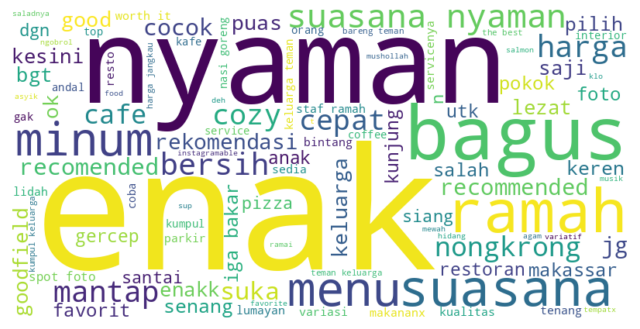

In [73]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nlp_id.stopword import StopWord

stopwords = StopWord()
stopwords_list = stopwords.get_stopword() + added_stopwords

text = high_rating['lemmatized'].str.cat(sep=' ')

# Generate the word cloud object
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=stopwords_list,
    max_words=100, # Limit the number of words
    min_font_size=10
).generate(text)

plt.figure(figsize=(8, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [77]:
pd.set_option('display.max_colwidth', None)

low_rating = reviews_cust[reviews_cust['rating'] < 3].iloc[:].get(["nama", "reviews", "cleaned_reviews", "lemmatized"])

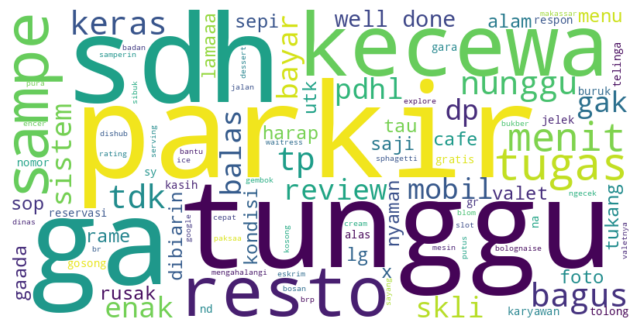

In [78]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nlp_id.stopword import StopWord

stopwords = StopWord()
stopwords_list = stopwords.get_stopword() + added_stopwords

text = low_rating['lemmatized'].str.cat(sep=' ')

# Generate the word cloud object
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=stopwords_list,
    max_words=100, # Limit the number of words
    min_font_size=10
).generate(text)

plt.figure(figsize=(8, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [79]:
low_rating[low_rating['reviews'].str.contains('parkir')]

,nama,reviews,cleaned_reviews,lemmatized
0,jani,"Makanannya enak dan penyajiannya cukup cepat. Namun sayangnya pengalaman kami setelah bukber di sini sangat mengecewakan. Mobil kami digembok Dishub karena parkir di badan jalan, padahal kami parkir di situ karena diarahkan oleh tukang …",makanannya enak penyajiannya cepat sayangnya pengalaman bukber mengecewakan mobil digembok dishub parkir badan jalan parkir diarahkan tukang,makan enak saji cepat sayang alam bukber kecewa mobil gembok dishub parkir badan jalan parkir arah tukang
18,Andre Michael,"Petugas valet sangat tidak membantu, saya menunggu 30 menit lebih di depan parkiran dalam kondisi saya tidak tau kalau tempat nya punya petugas valet Dan ada Mobil parkir mengahalangi slot parkiran yang kosong ,petugas petugas valetnya …",petugas valet membantu menunggu menit parkiran kondisi tau petugas valet mobil parkir mengahalangi slot parkiran kosong petugas petugas valetnya,tugas valet bantu tunggu menit parkir kondisi tau tugas valet mobil parkir mengahalangi slot parkir kosong tugas tugas valetnya
290,Austin Oendy,"Tolong saya jadi malas makan gara gara tukang parkirnya, masa di kasih 3000 maksa minta 5000 sampai mobil saya di kejar"" Padahal posisi parkiran lagi sepi aneh bgt gr gr itu jadi ga bakal saya makan disini lg",tolong malas makan gara gara tukang parkirnya kasih maksa mobil kejar posisi parkiran sepi aneh bgt gr gr ga makan lg,tolong malas makan gara gara tukang parkir kasih maksa mobil kejar posisi parkir sepi aneh bgt gr gr ga makan lg


**insight**:
- Tukang parkir yang tidak bertanggung jawab, bebaskan dari tukang parkir liar

In [64]:
pd.set_option('display.max_colwidth', None)

reviews_cust[reviews_cust['rating'] < 4].iloc[:].get(["nama", "cleaned_reviews"])

,nama,cleaned_reviews
0,jani,makanannya enak penyajiannya cepat sayangnya pengalaman bukber mengecewakan mobil digembok dishub parkir badan jalan parkir diarahkan tukang
4,Falah Putra Caesarianto (Putra),memutuskan explore google review foto foto rating reviews dinas cafe resto makassar mengalami kekecewaan berharap
9,Hendhy Rahakbauw,pesan menu ice cream utk dessert dibiarin menunggu sampe jam waitress pura sibuk ngecek bosan x samperin mesin eskrim rusak blom paksaa serving encer
18,Andre Michael,petugas valet membantu menunggu menit parkiran kondisi tau petugas valet mobil parkir mengahalangi slot parkiran kosong petugas petugas valetnya
20,Joly Zhang,makanan enak menunggu makanan menit resto sepi pesan sphagetti bolognaise menit br resto ga sop brp serve makanan x kondisi pesan pizza wita sdh
30,Rizky Edy Shafira,bintang bagus review resto dibiarin nunggu makanan sampe jam ga dateng alesan orderan gaada info gaada konfirmasi ga lg wasting time please pay attention
33,Nurul Chairany,suasananya nyaman interior cantik pasta boscaiola pesan berbau kambing khas mual mencium aromanya
51,Yunita,sorry makannya pdhl tempatnya trus lamaaa skli menit utk menu pdhl gak rame meja terisi
52,Mwona Lysa,malam goodfiels menghadapi tamu makanan kluar jam pemesanan lamaaa bangettt ntah karyawan chefnya gimana pointnya mengecewakan
61,afifah rifa,menunggu makanan jam resto lgi tdk rame


In [65]:
wordcloud